In [16]:
import os
import numpy as np
import pymc as pm
import pytensor
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
if os.environ.get("SIMPLEVI_PYTENSOR_CXX"):
    pytensor.config.cxx = os.environ["SIMPLEVI_PYTENSOR_CXX"]
from tqdm.notebook import tqdm

from modulars.distributions import gaussian_multid, gaussian_multid_posterior, ensure_arr
from modulars.utils import check_all_int_or_float_or_1darrays, check_all_covar_shaped_arrays
from modulars.pymc_rr_test import run_single_seed_pymc_fullrank_VI, run_pymc_fullrank_VI

In [17]:
# this is 40 dimensions
mu_prior = np.zeros(40)
sigma_prior = np.ones(40) * 10 # diag std of prior
mu_like = 2.0
sigma_like = 1.0 # std of likelihood
max_iters = 30_000
n_obs = 3
dim = 40
np.random.seed(42)

DIAG = True

# Generate observations for each dimension
observed_data = gaussian_multid(
    seed=42, n_samples=n_obs, mu_like=mu_like,
    scale_like=sigma_like, dim=dim)
# compute known posterior, this is the posterior diagonal standard deviation vector as true_sigma_post
true_mu_post, true_sigma_post = gaussian_multid_posterior(
    observed_data, n_samples=n_obs,
    mu_prior=mu_prior, scale_prior=sigma_prior**2,
    scale_like=1.0, std_devs=False,
    diag=DIAG, dim=40)

In [18]:
def run_model(n_mc_samples = 1, optimizer = 'default', seed = 1):
    with pm.Model() as model:
        mu = pm.Normal('mu', mu_prior, sigma_prior, shape=dim)
        likelihood = pm.Normal('y', mu, sigma=np.ones(dim), observed=observed_data)
        
        tracked_vals = run_pymc_fullrank_VI(model, n_mc_samples, 50_000, optimizer, seed, SINGLE_DIM=False)
    return tracked_vals


In [19]:
results = []
adam_results = []
for seed in tqdm(range(10)):
    all_results = run_single_seed_pymc_fullrank_VI(seed, run_model)
    results.append(all_results[0])
    adam_results.append(all_results[1])

  0%|          | 0/10 [00:00<?, ?it/s]

Finished [100%]: Average Loss = 260.77
Interrupted at 39,881 [79%]: Average Loss = 275.6
Finished [100%]: Average Loss = 260.71
Finished [100%]: Average Loss = 260.38
Finished [100%]: Average Loss = 260.76
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.73
Finished [100%]: Average Loss = 260.38
Finished [100%]: Average Loss = 260.75
Finished [100%]: Average Loss = 260.36
Finished [100%]: Average Loss = 260.72
Finished [100%]: Average Loss = 260.38
Finished [100%]: Average Loss = 260.77
Finished [100%]: Average Loss = 260.36
Finished [100%]: Average Loss = 260.69
Finished [100%]: Average Loss = 260.38
Finished [100%]: Average Loss = 260.73
Finished [100%]: Average Loss = 260.35
Finished [100%]: Average Loss = 260.69
Finished [100%]: Average Loss = 260.38
Finished [100%]: Average Loss = 260.81
Finished [100%]: Average Loss = 260.36
Finished [100%]: Average Loss = 260.69
Finished [100%]: Average Loss = 260.38
Finished [100%]: Average Loss = 260.8
Finished [100%]

In [ ]:
%matplotlib inline
from modulars.utils import apply_traj_transform_multid
single_means, single_covs, multi_means, multi_covs = \
    apply_traj_transform_multid(results, PYMC=True)

adam_single_means, adam_single_covs, adam_multi_means, adam_multi_covs = \
    apply_traj_transform_multid(adam_results, PYMC=True)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
single_means.shape, single_covs.shape, multi_means.shape, multi_covs.shape

((10, 50000, 40), (10, 50000, 40), (10, 50000, 40), (10, 50000, 40))

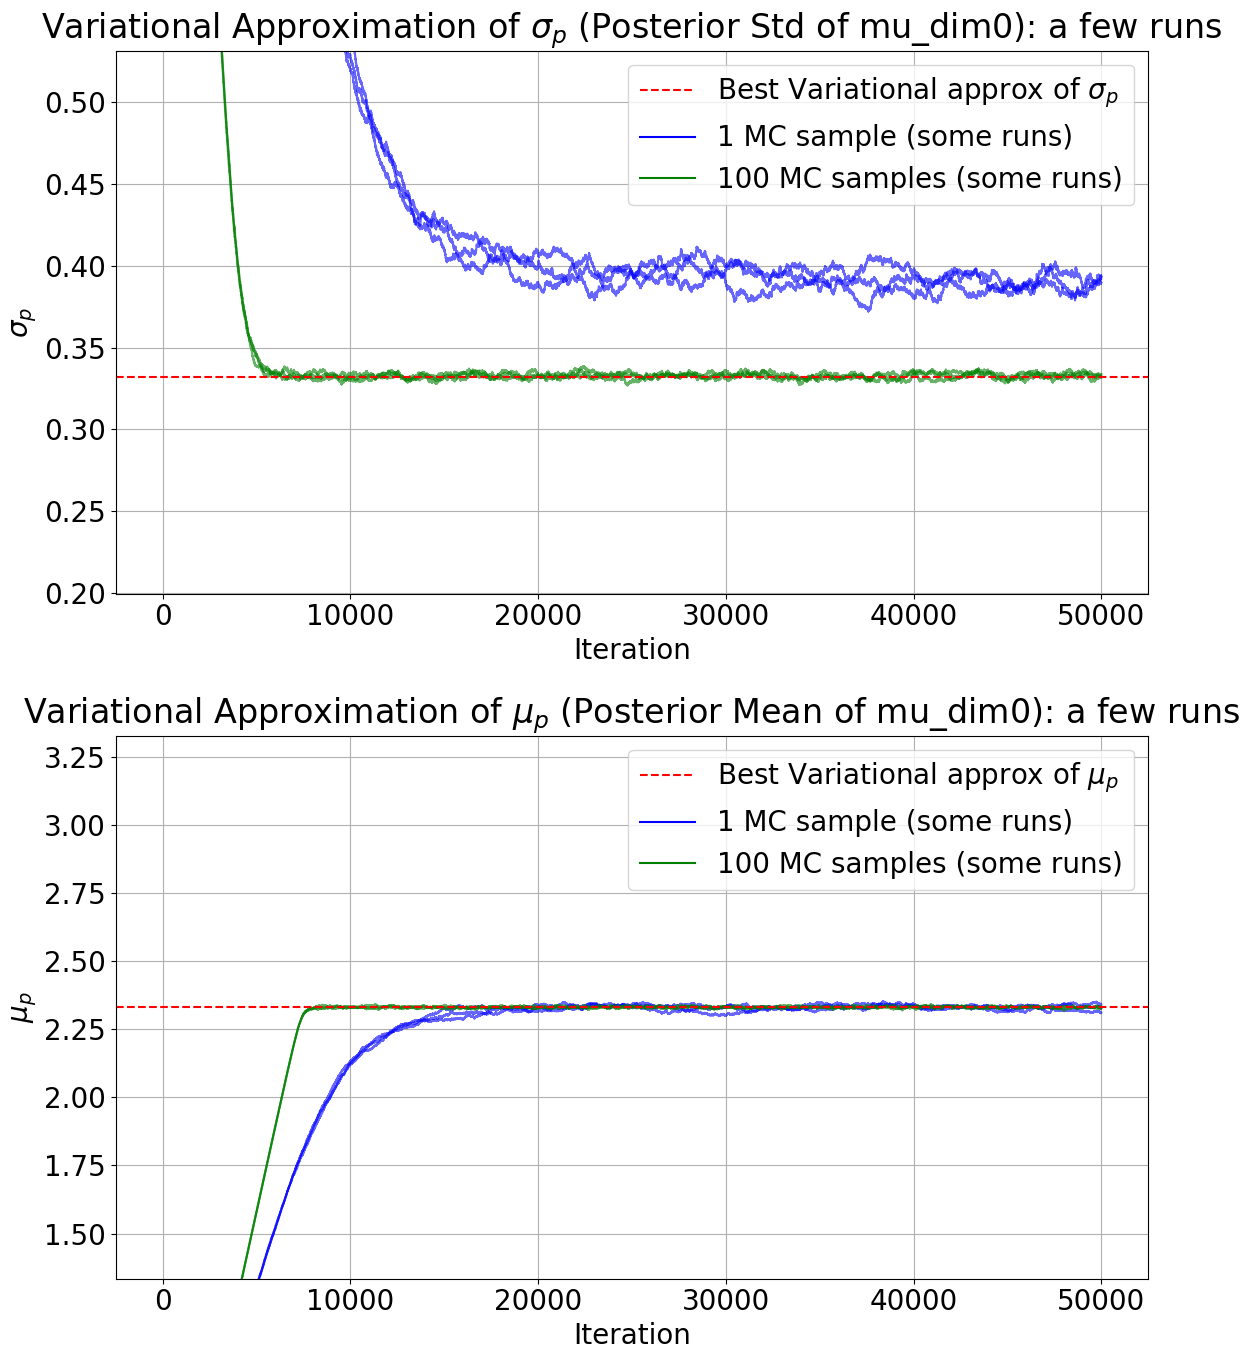

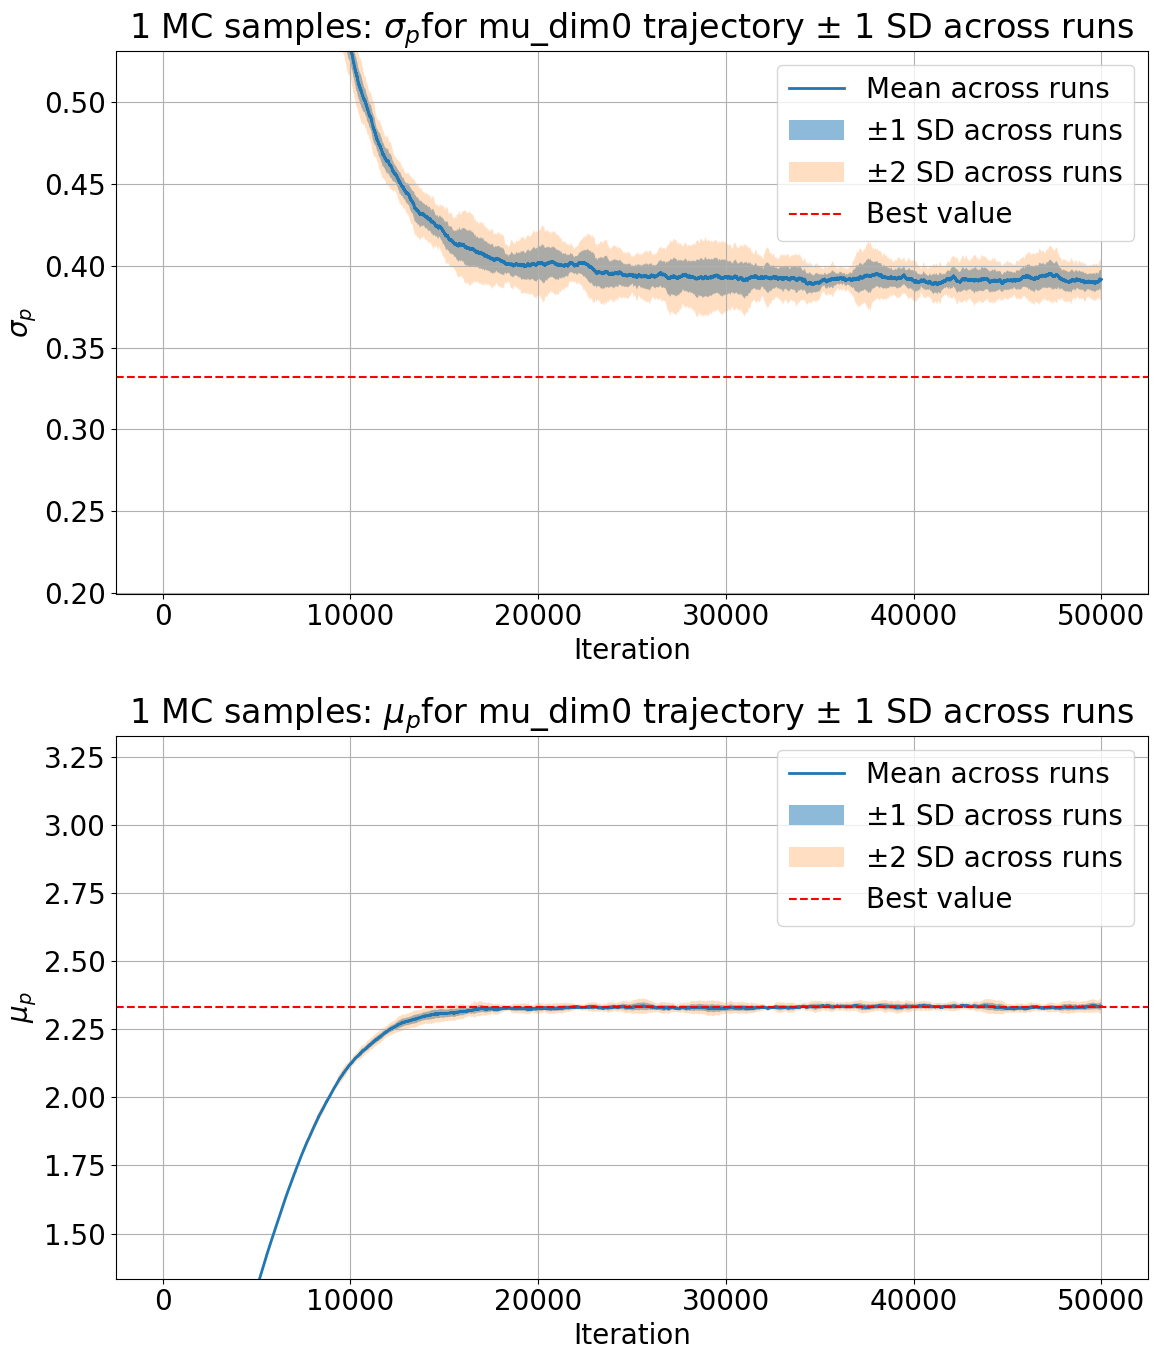

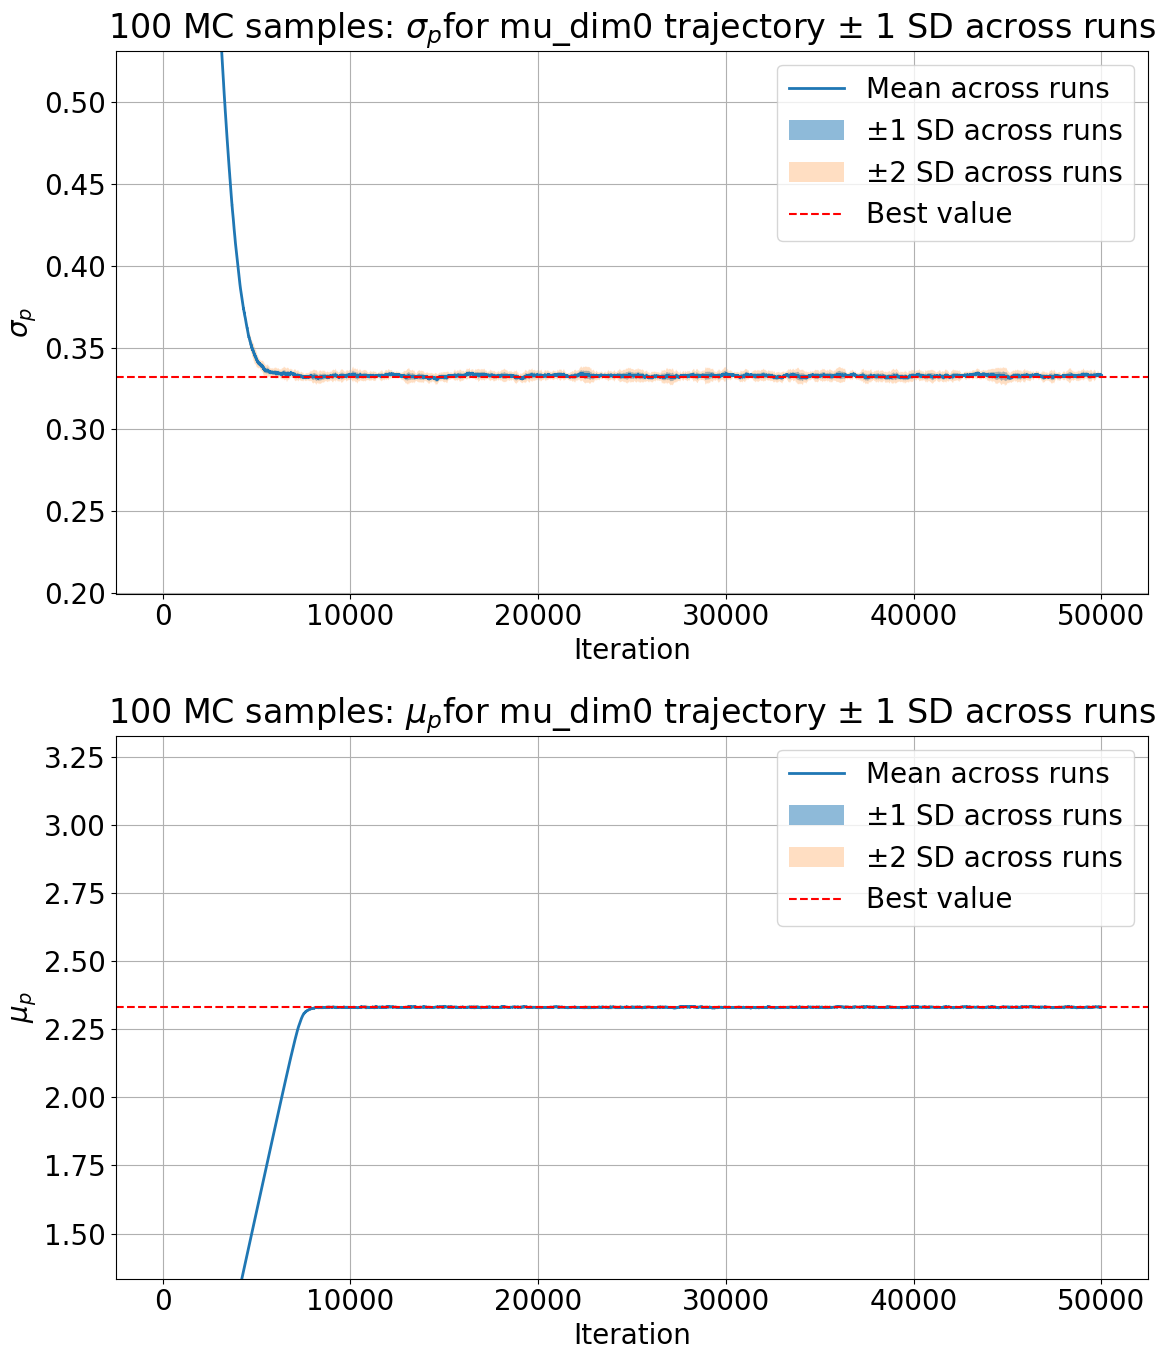

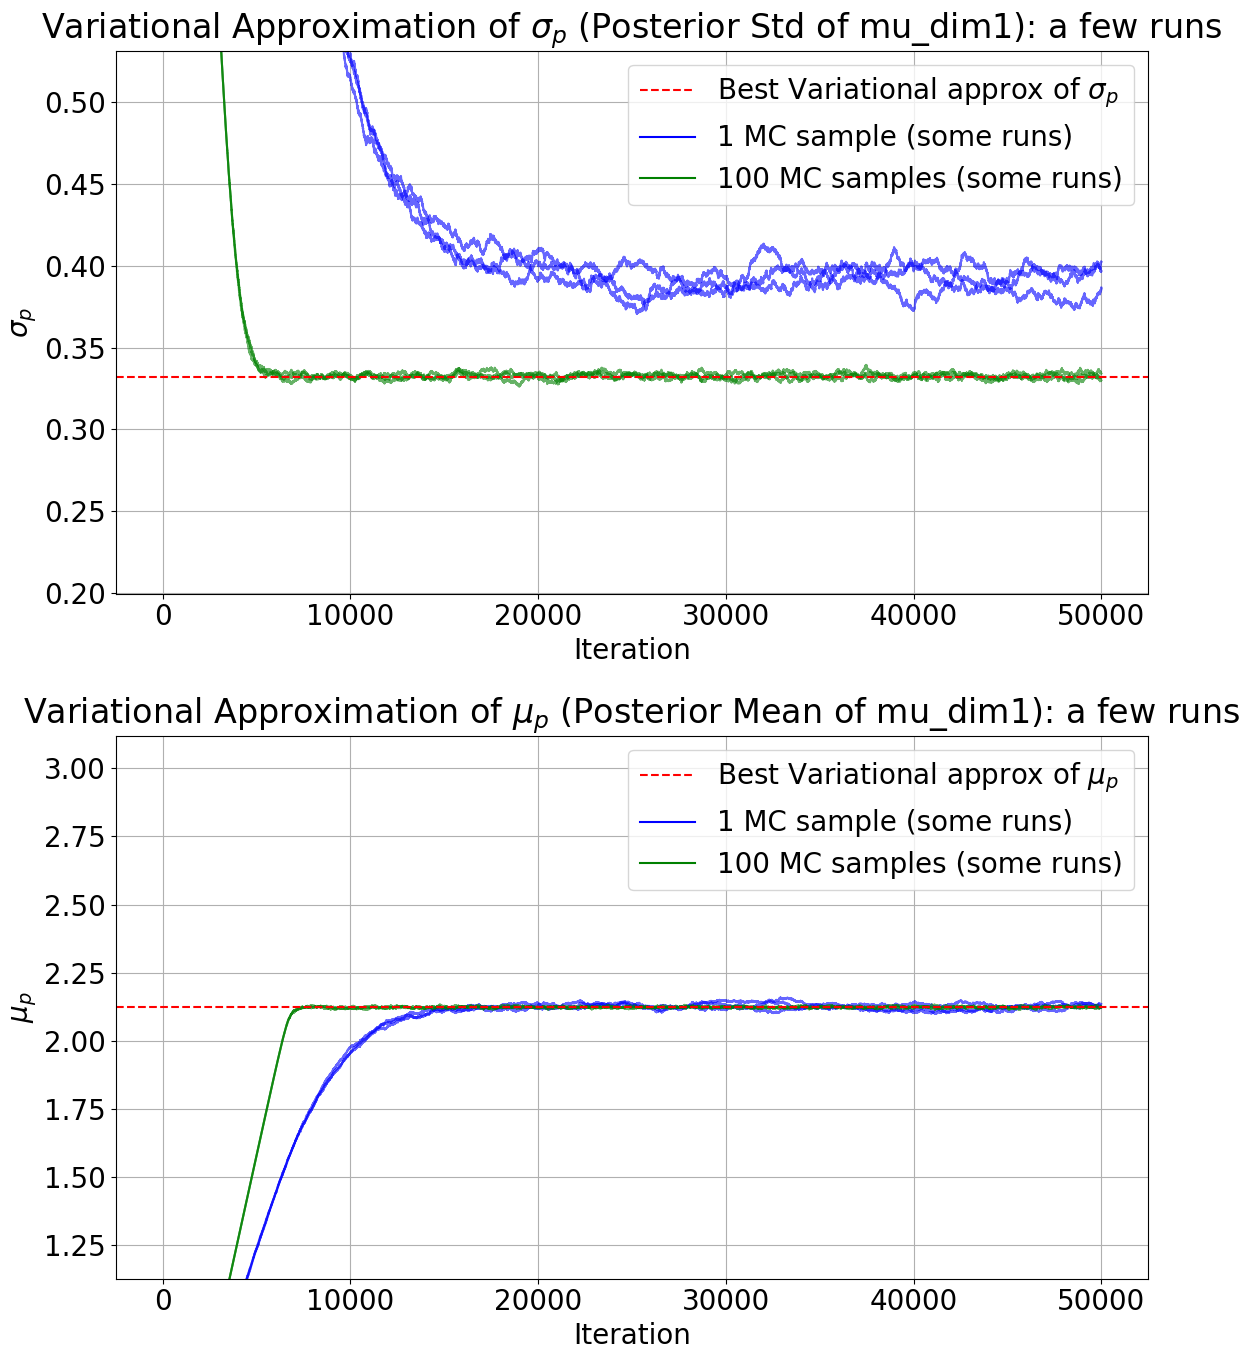

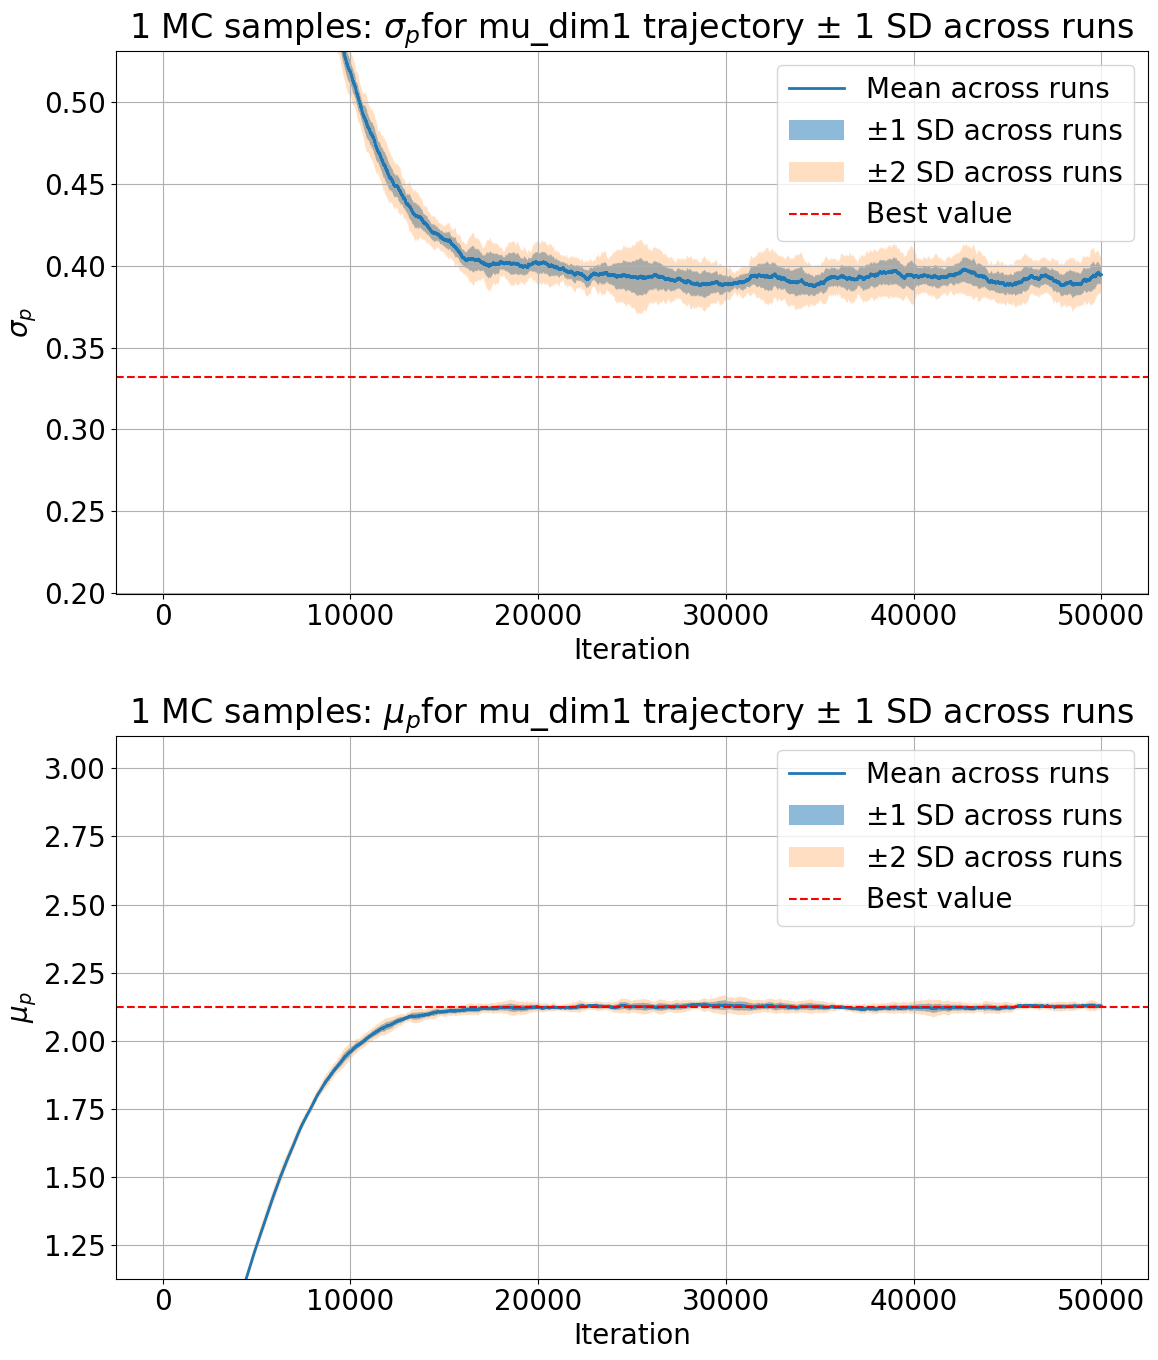

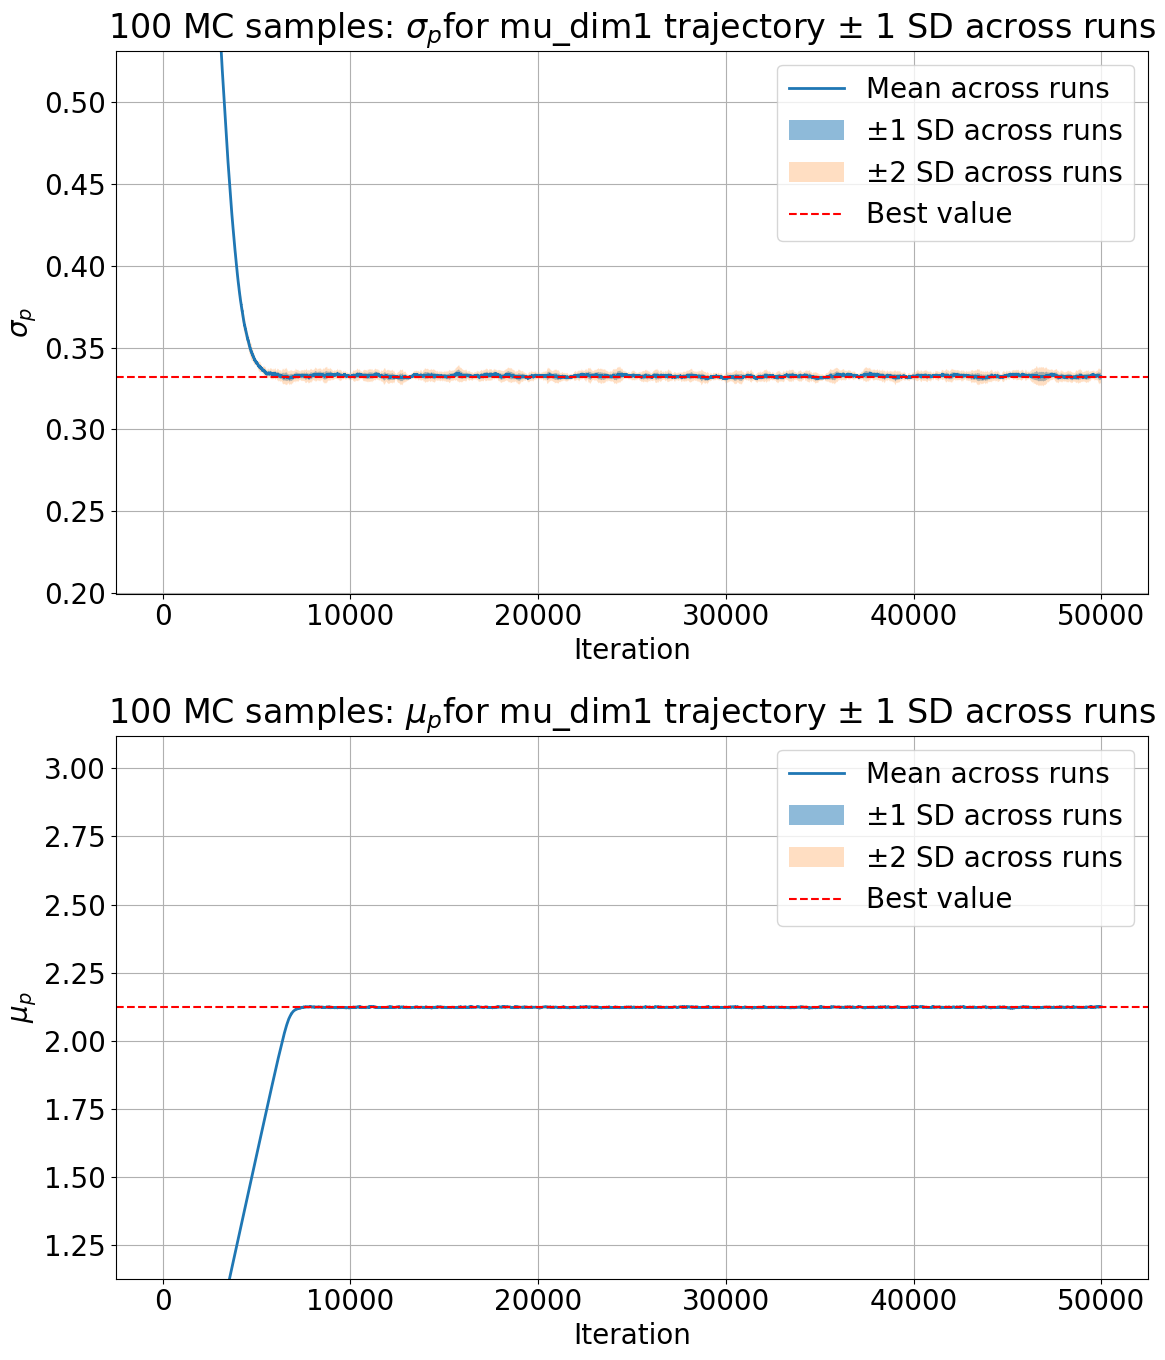

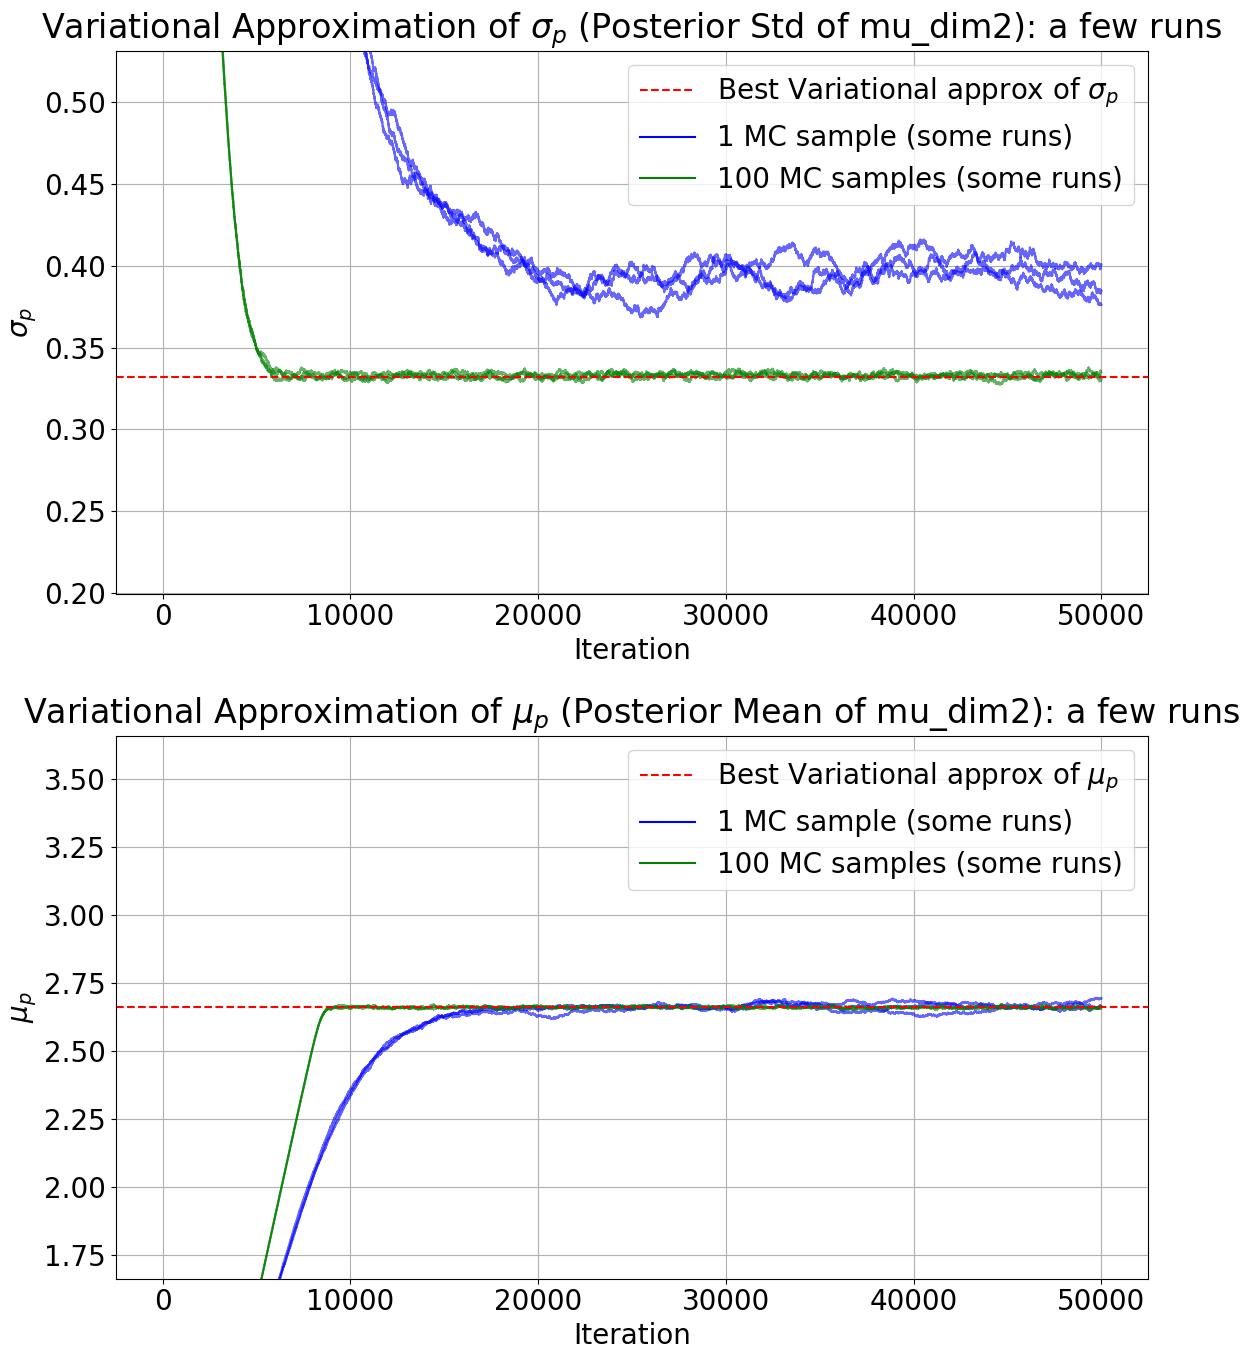

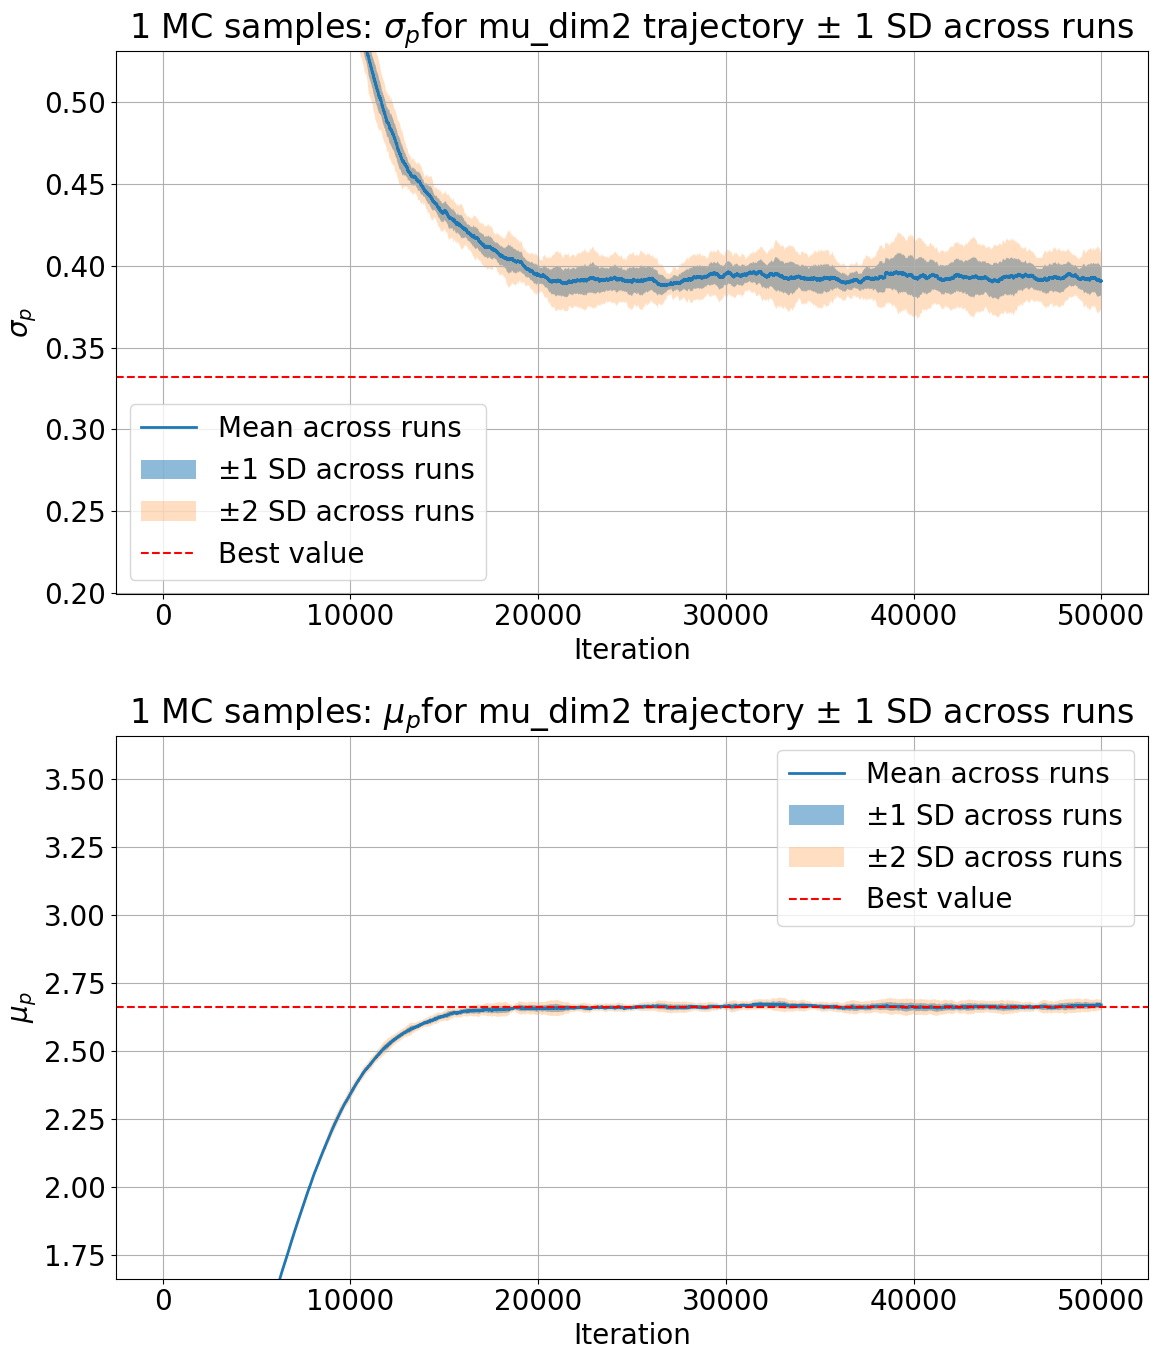

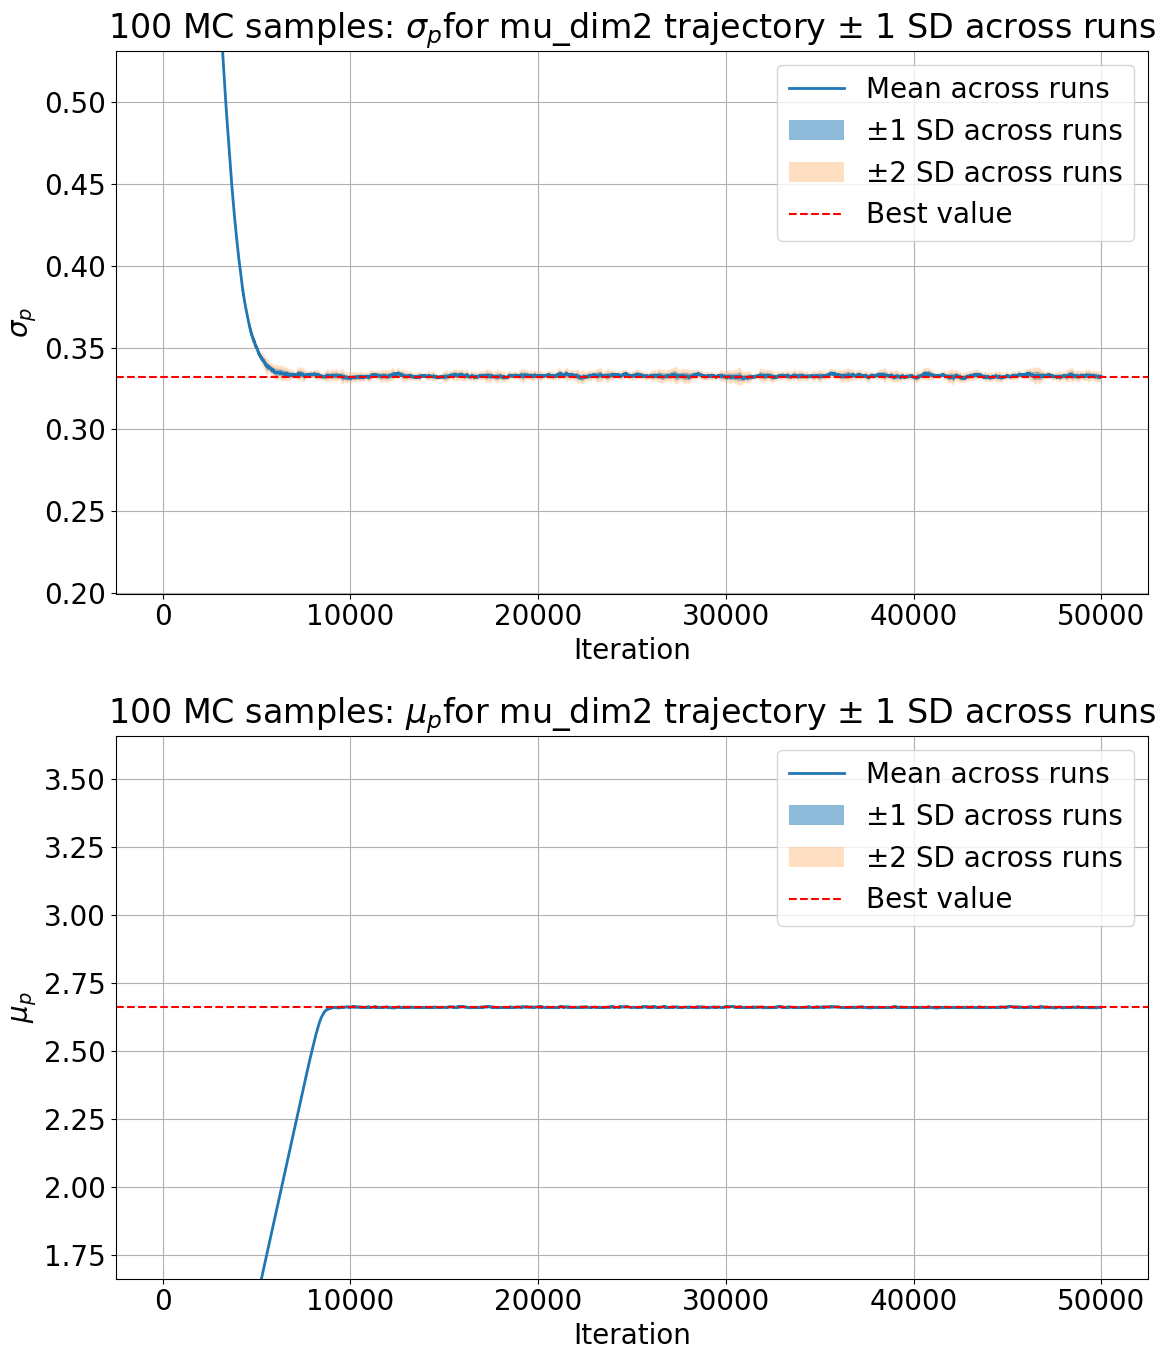

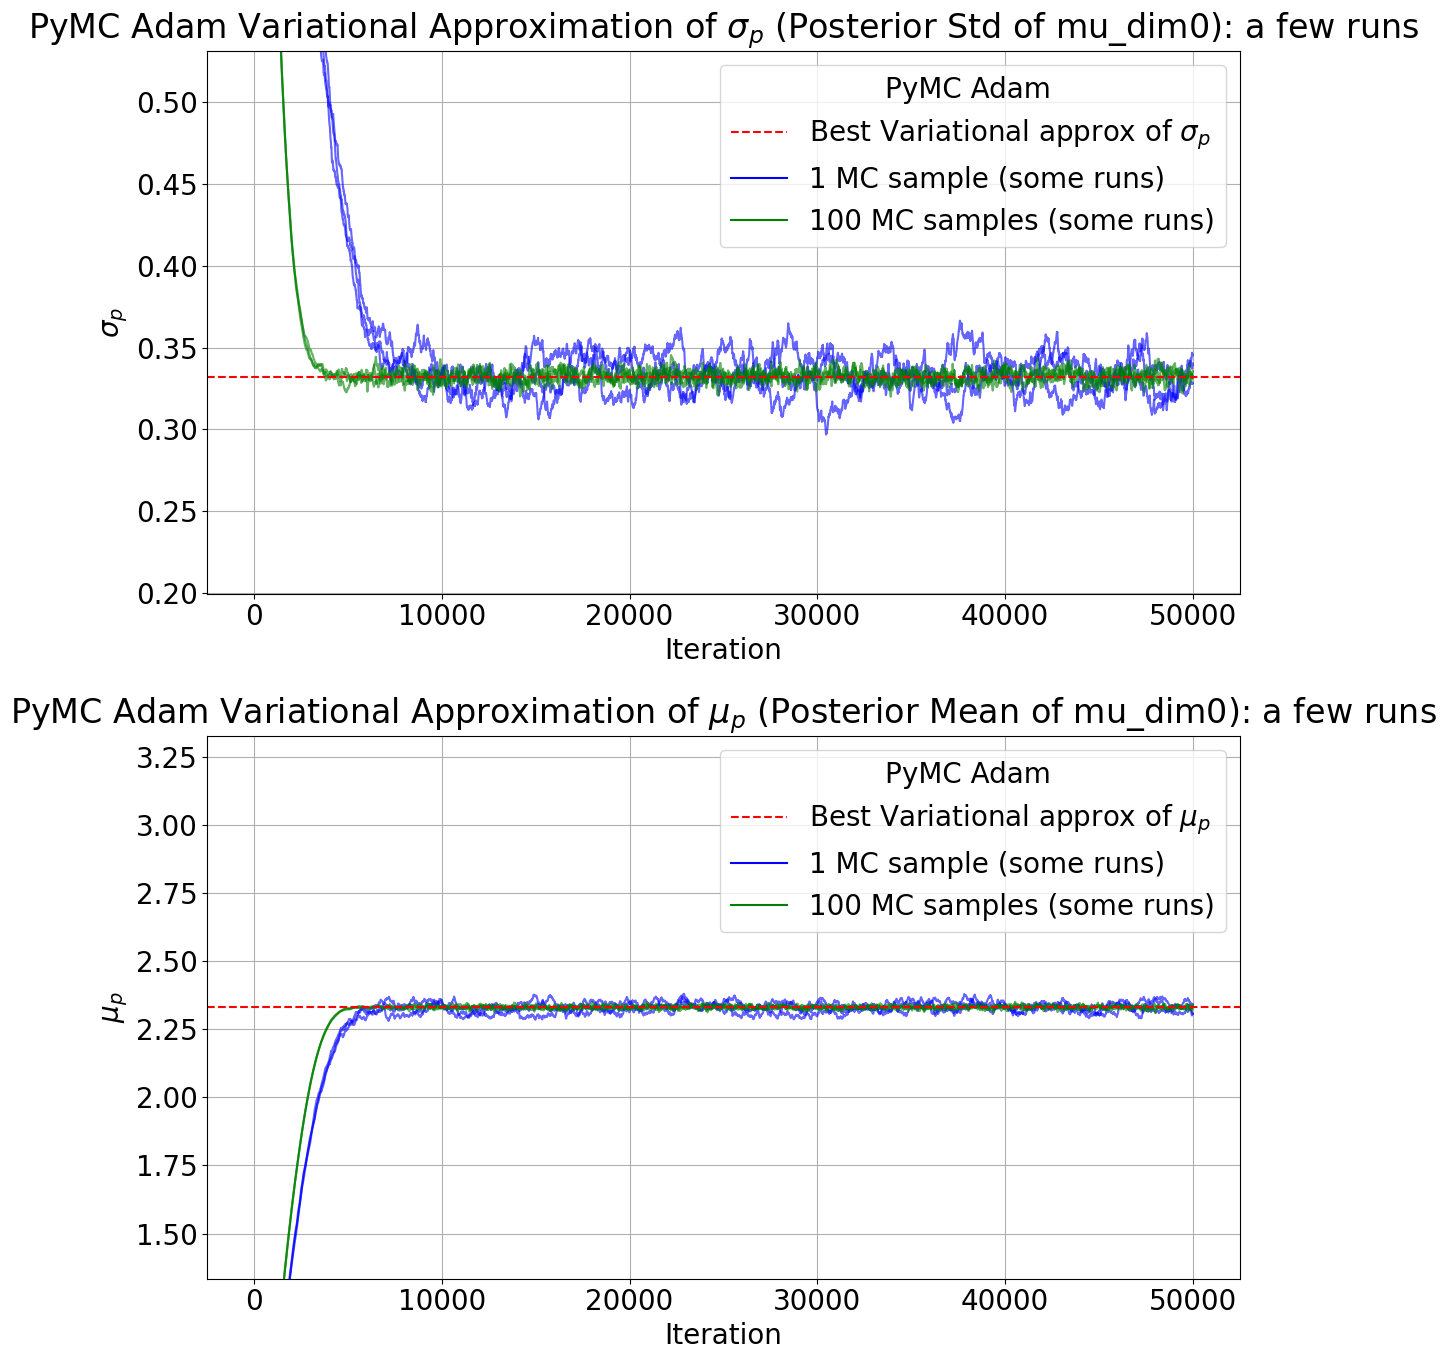

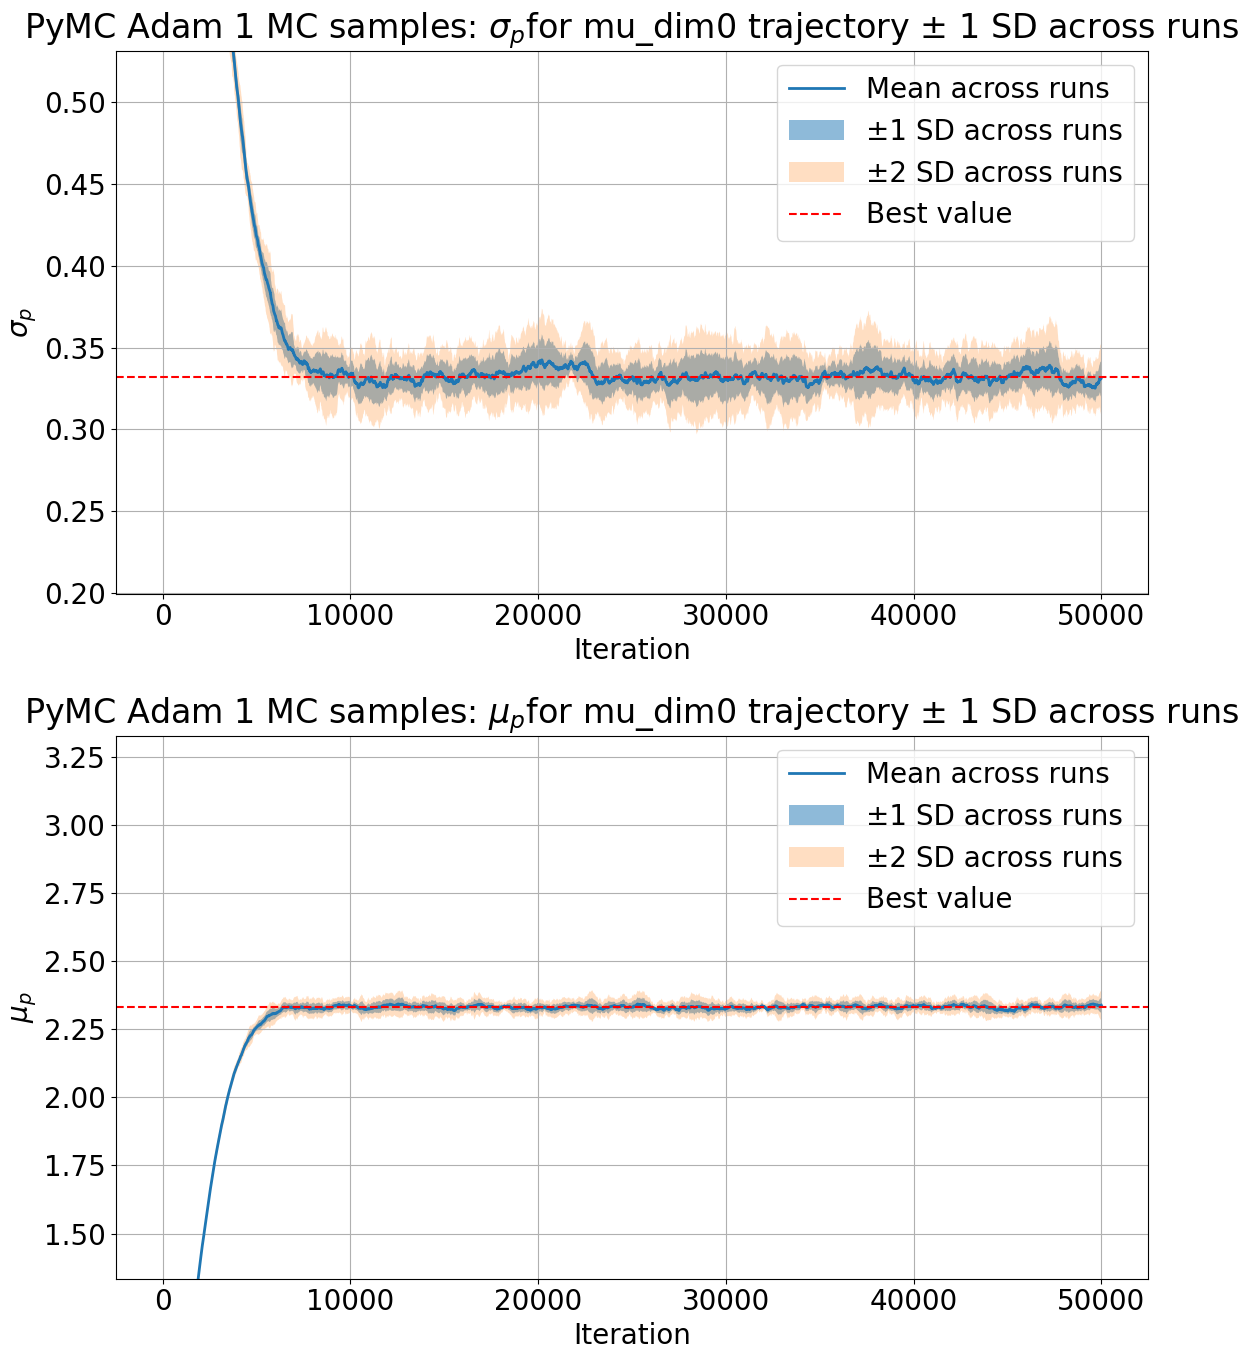

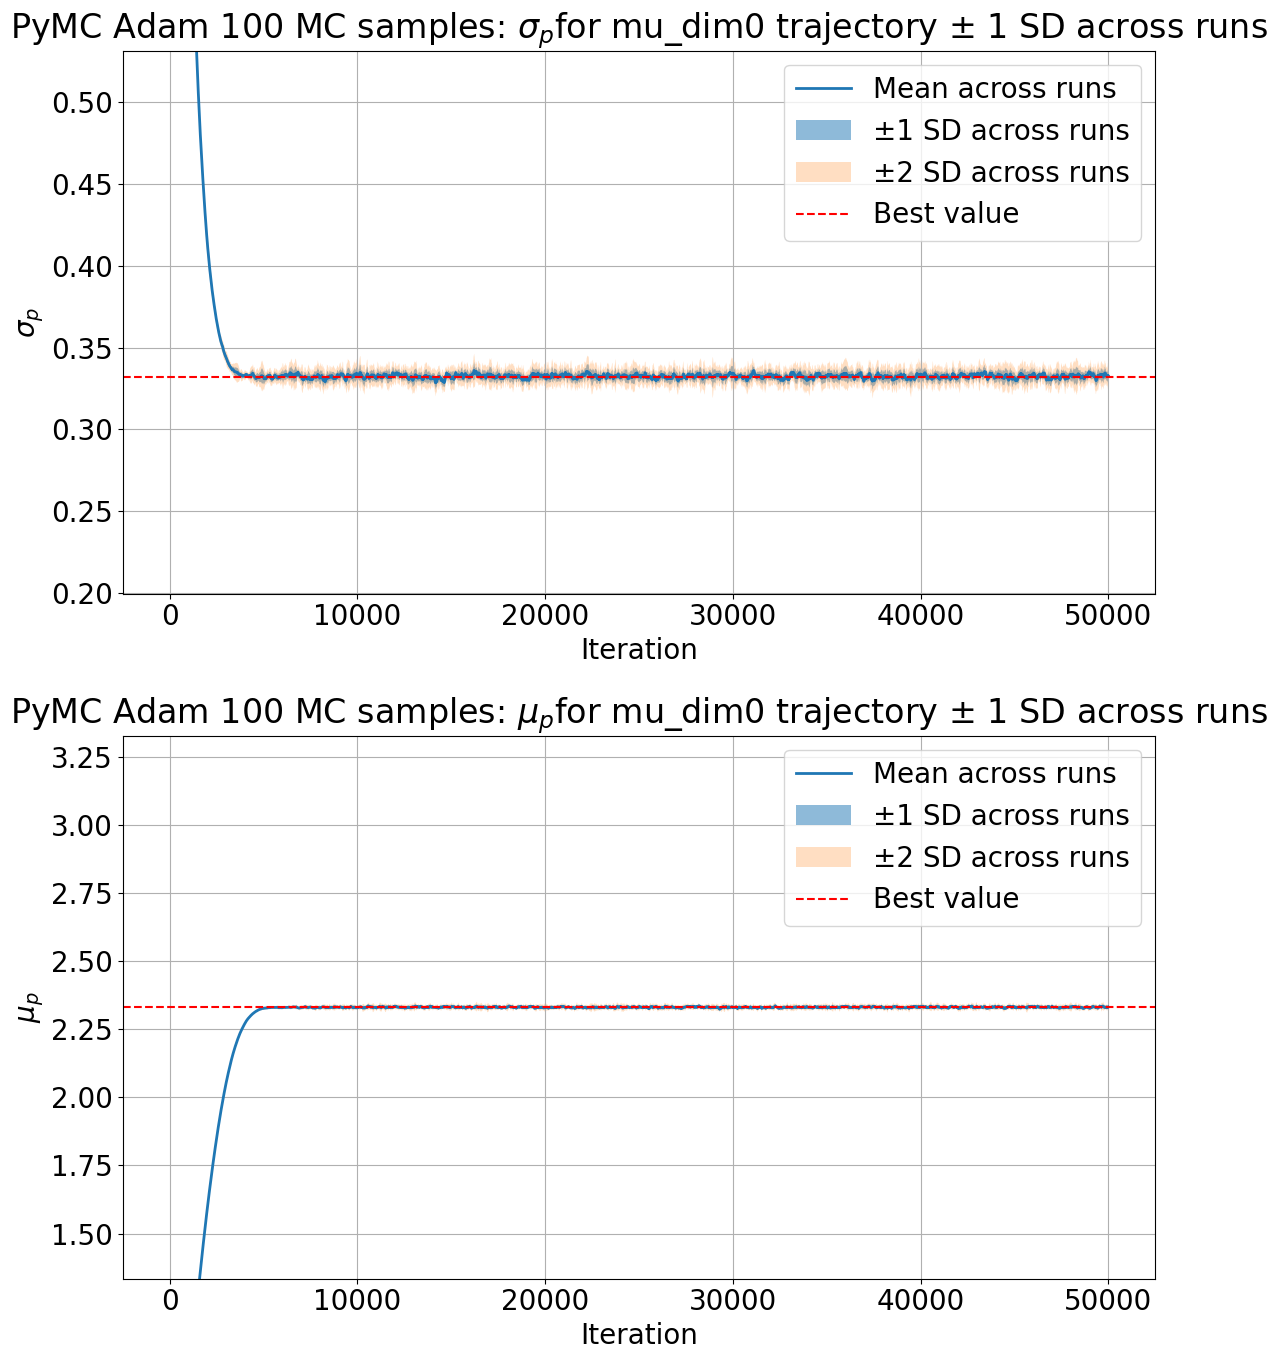

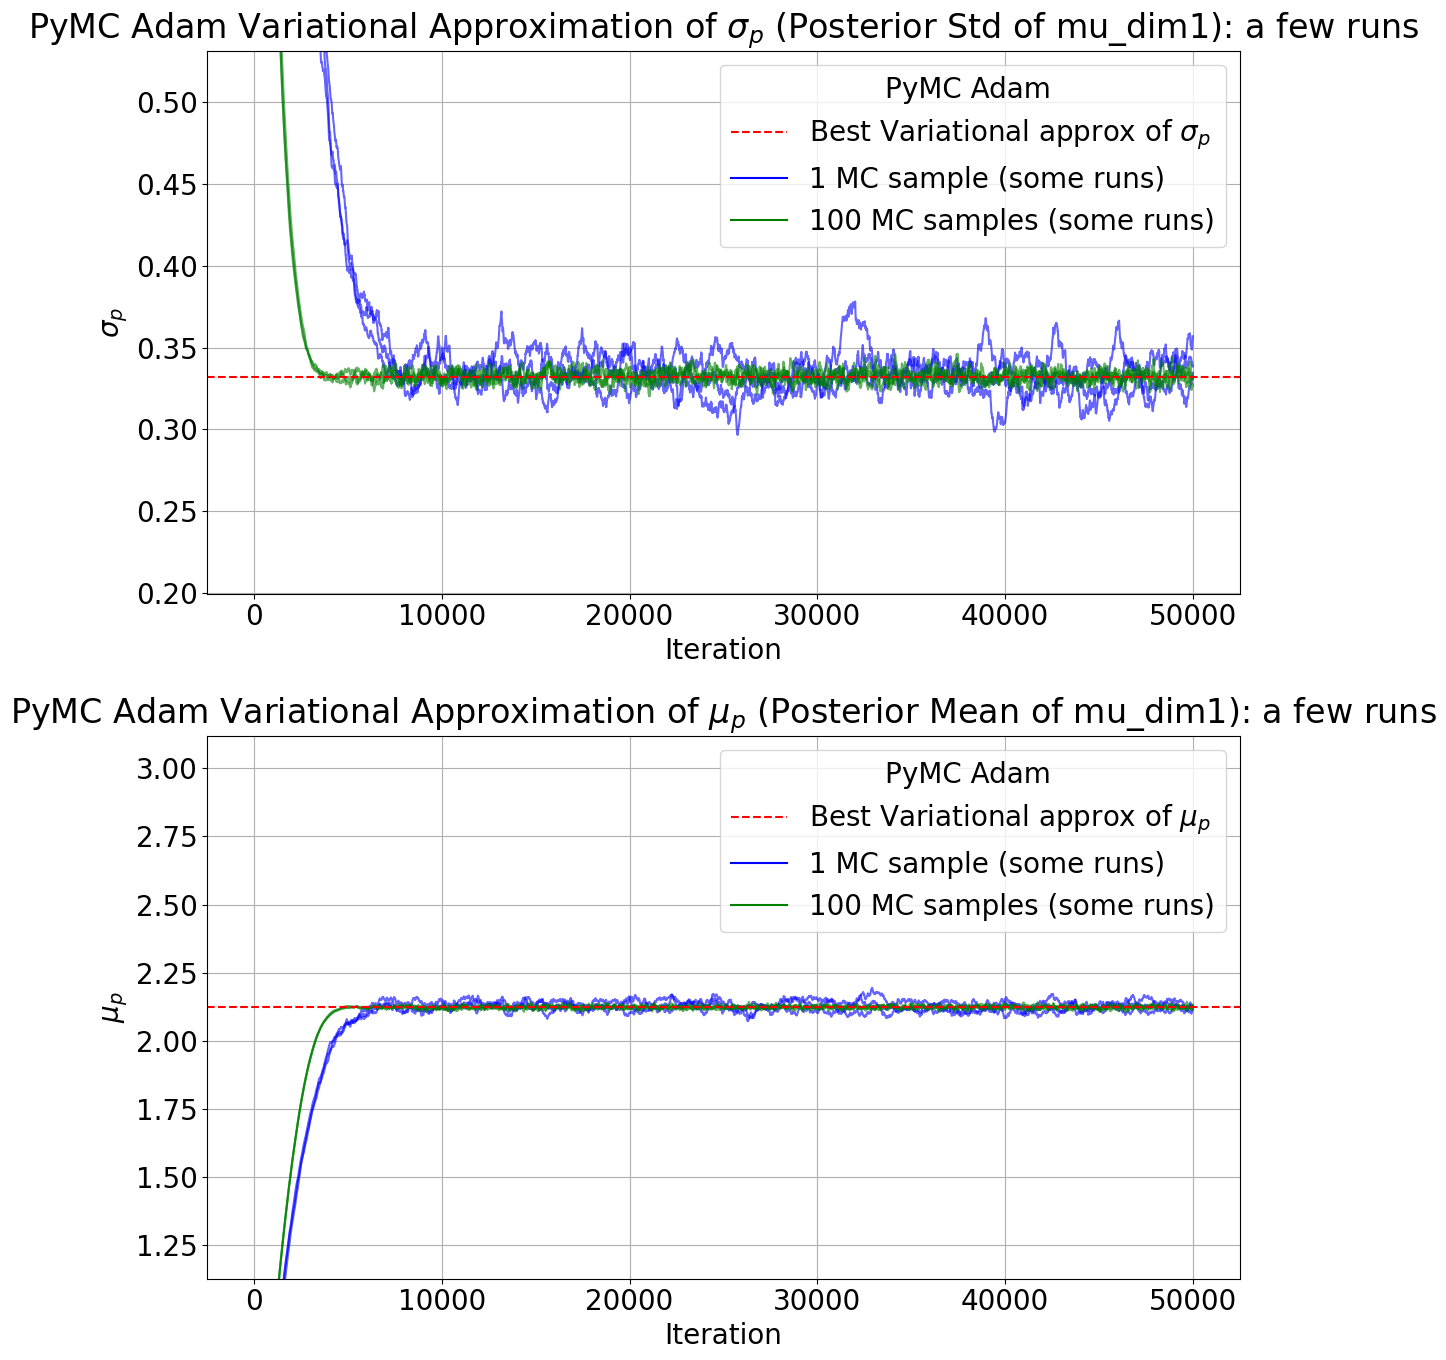

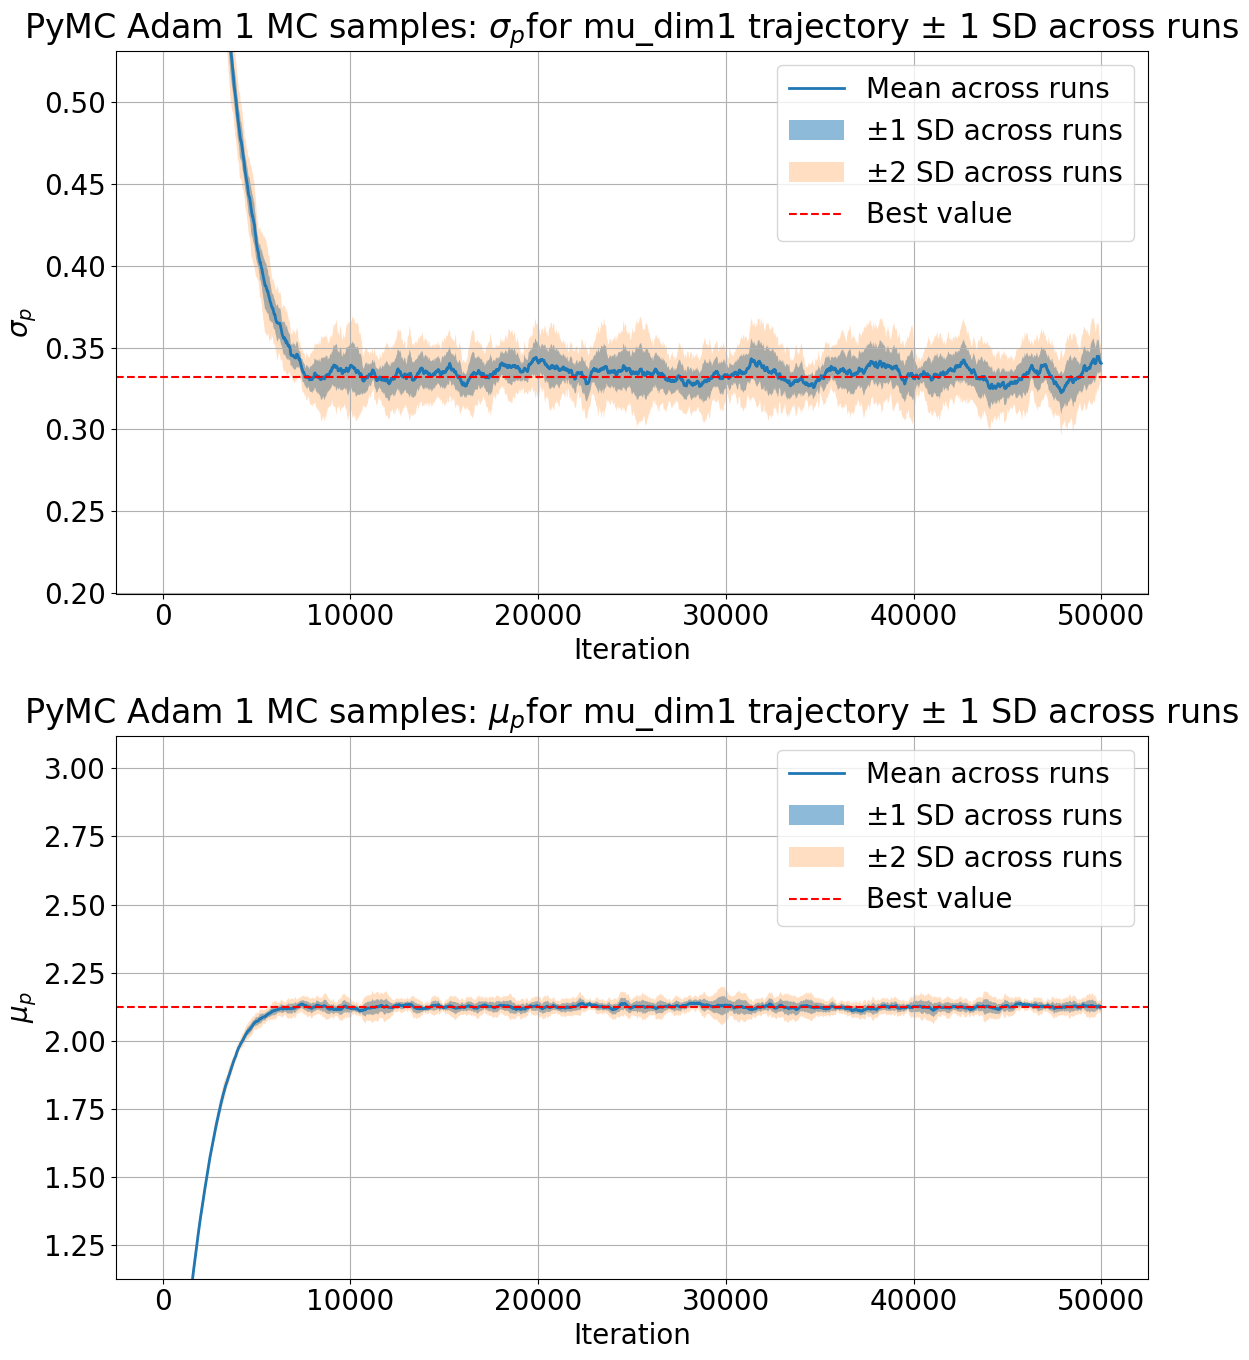

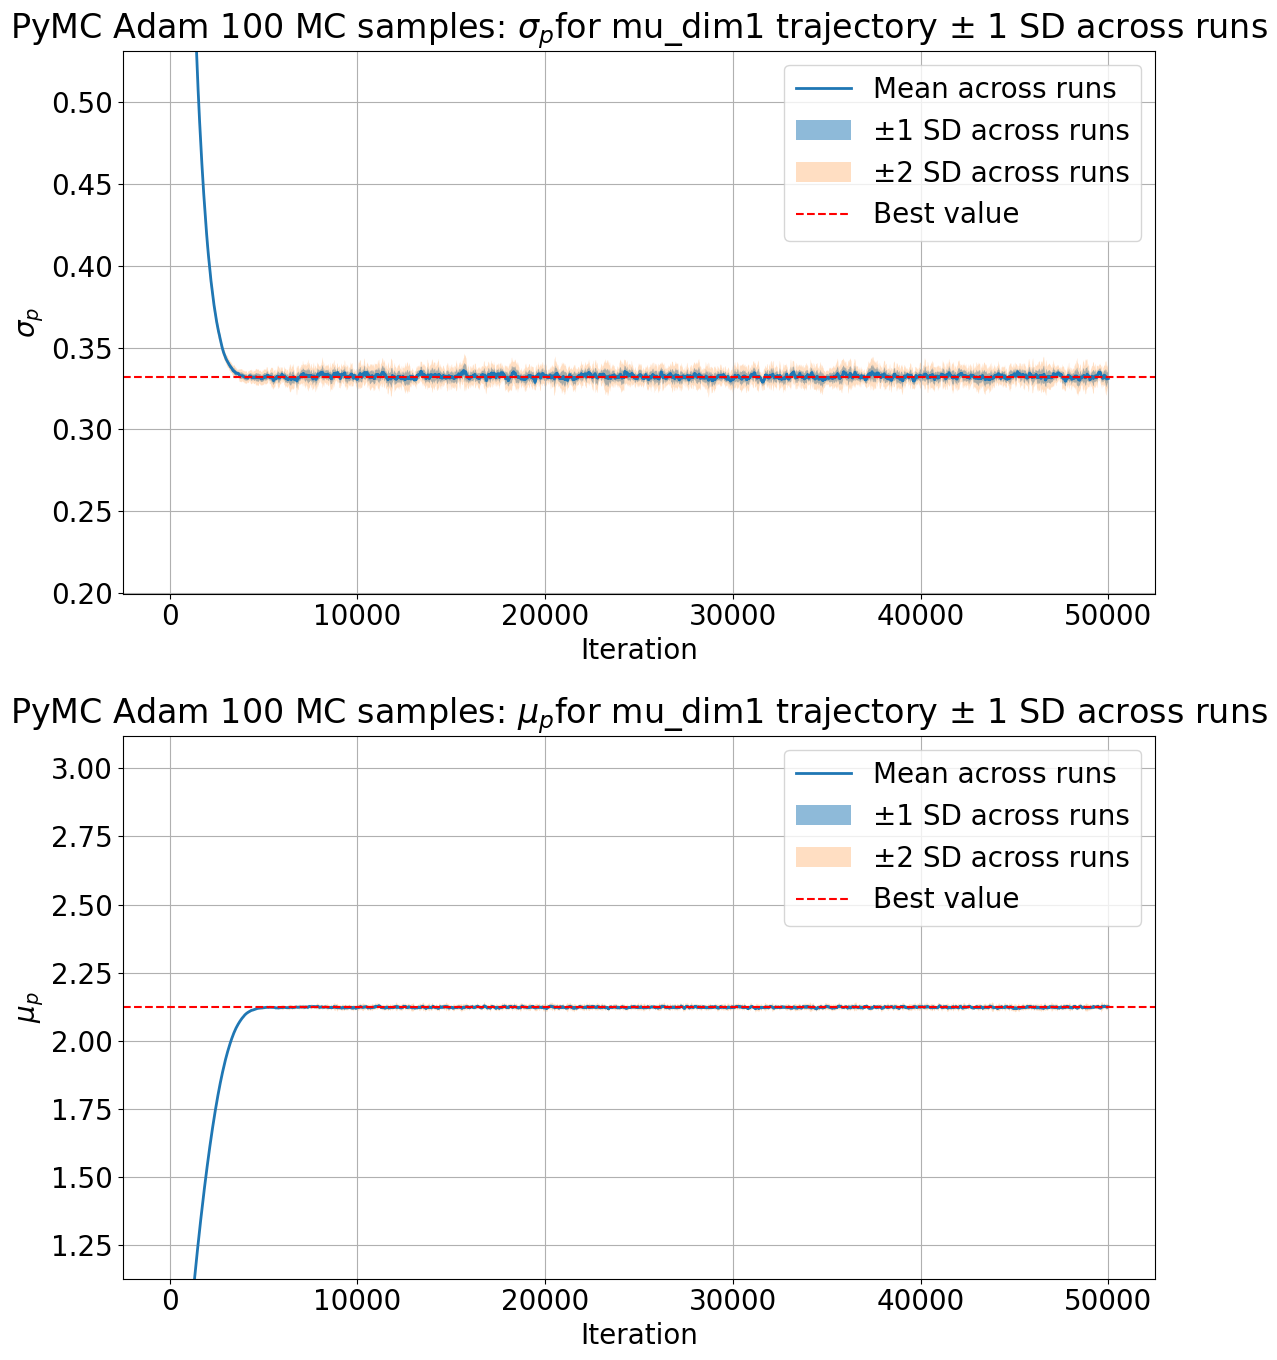

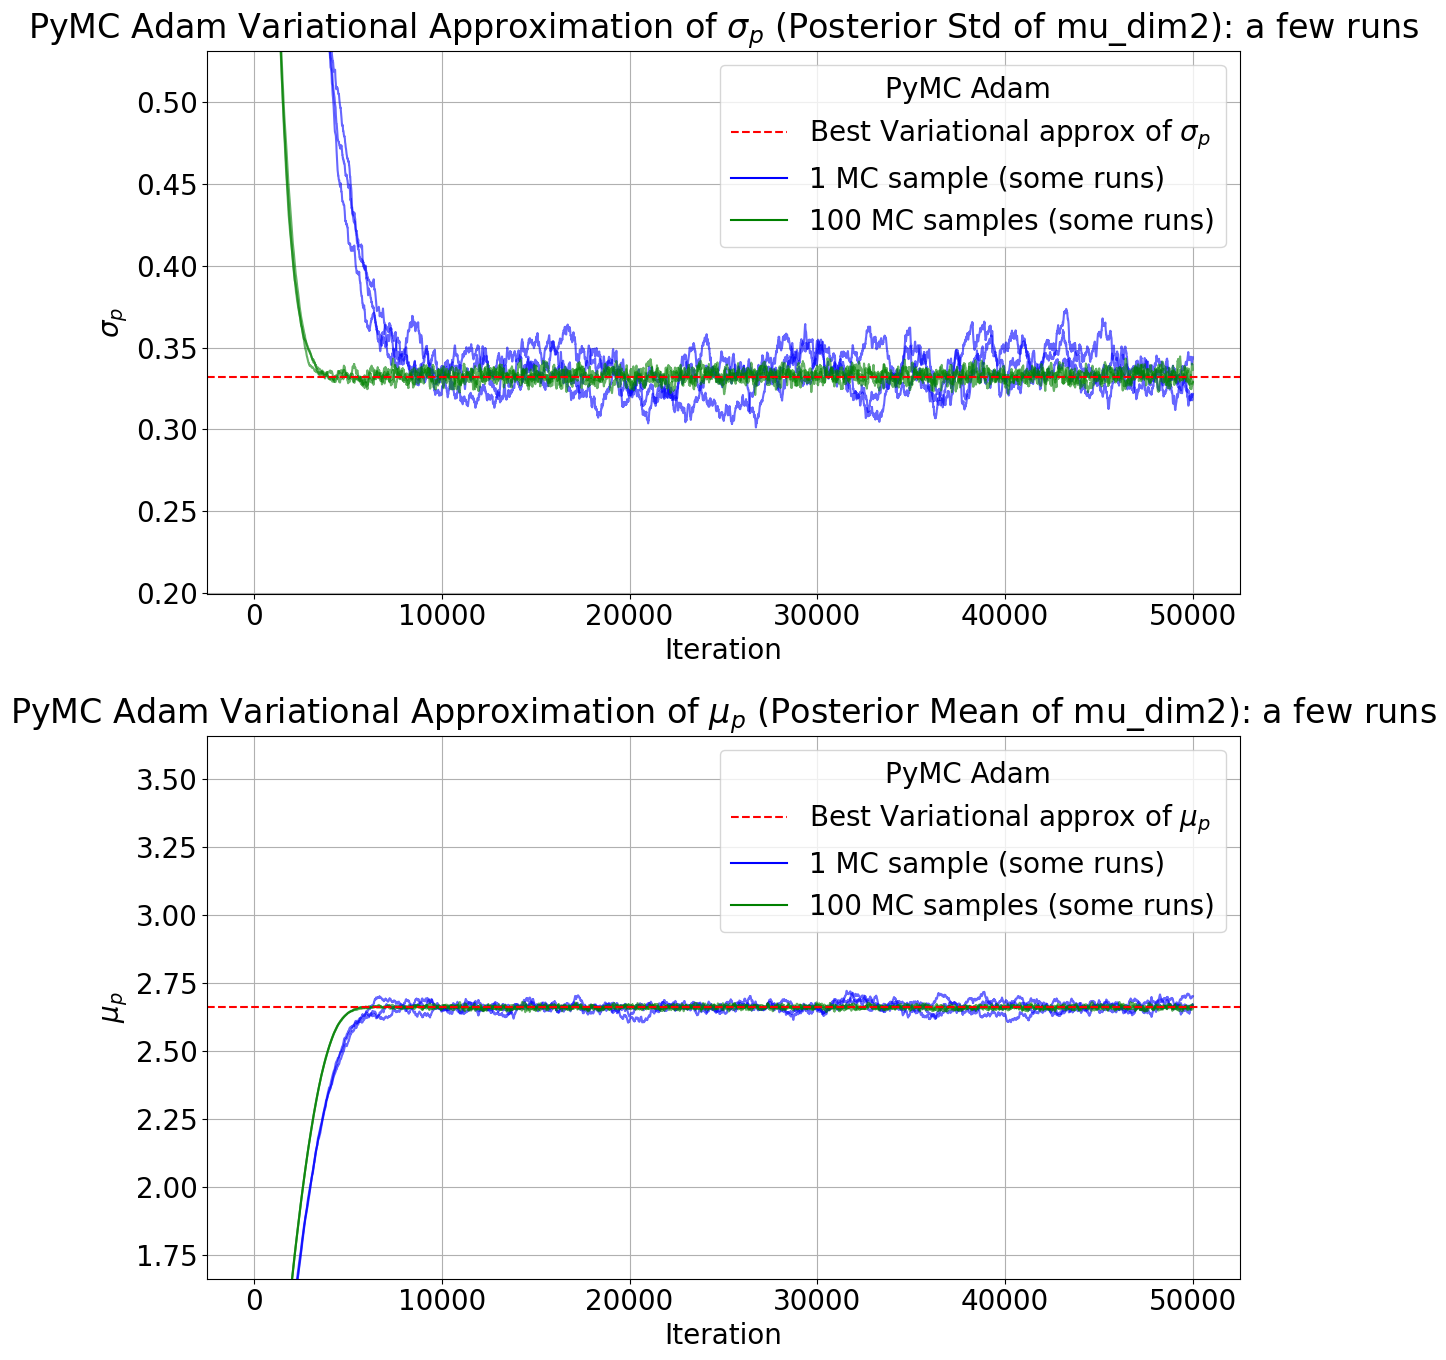

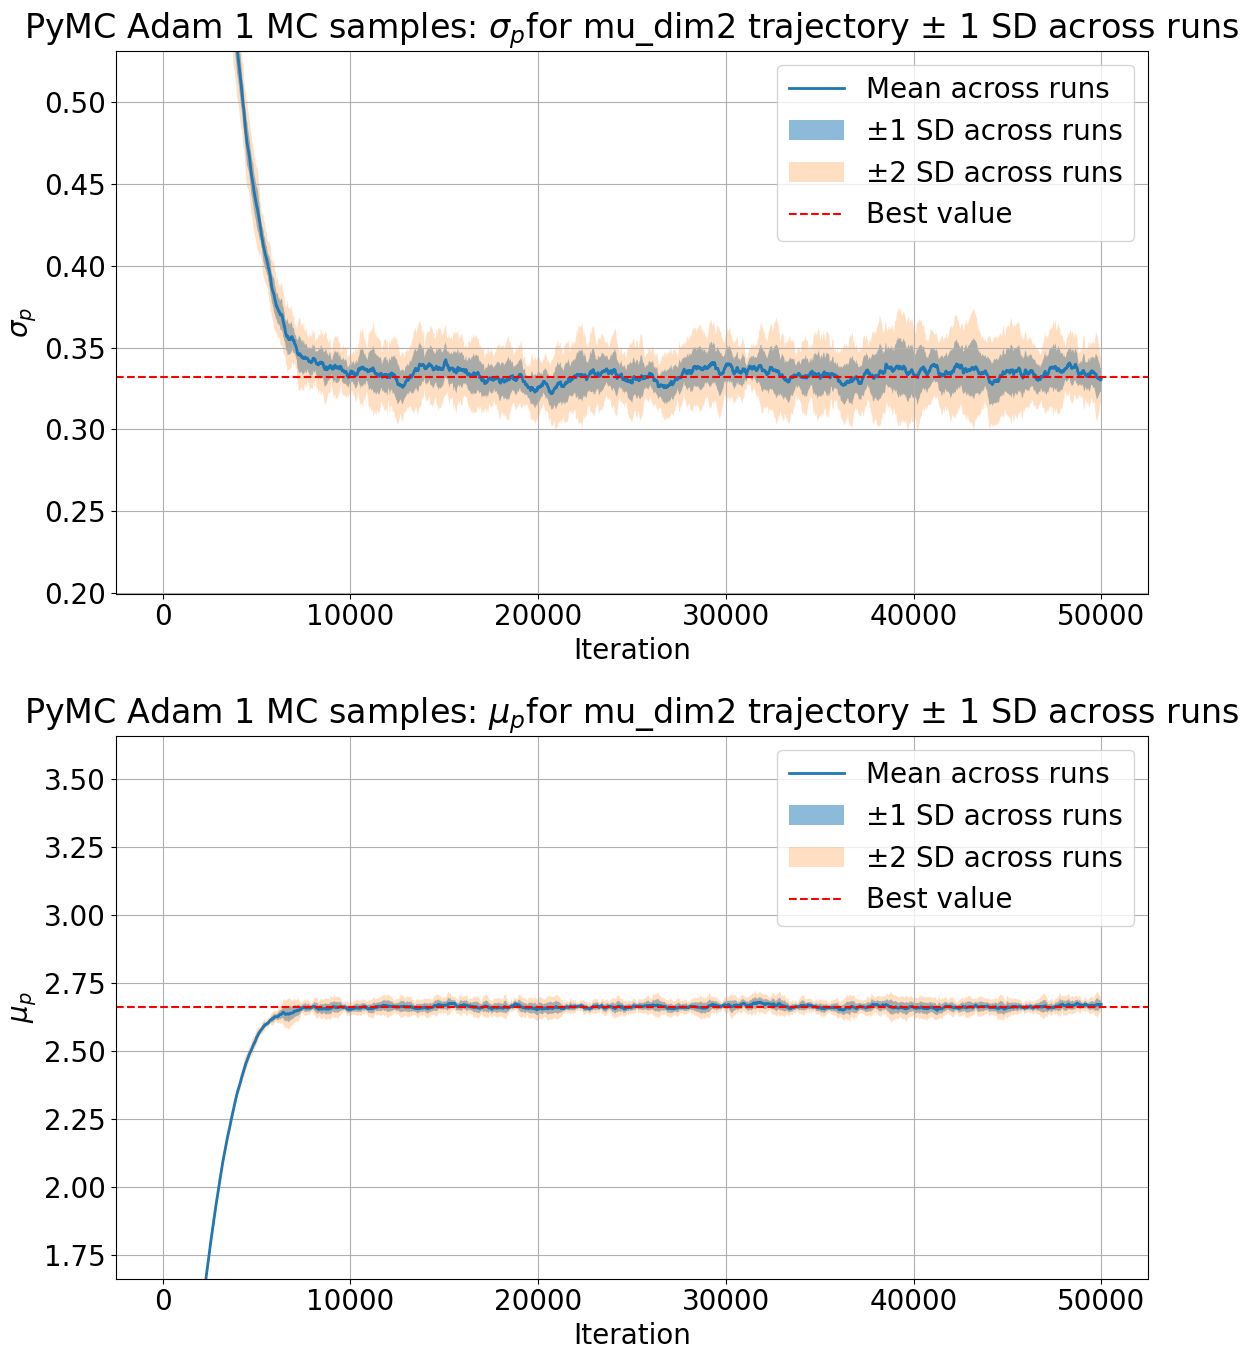

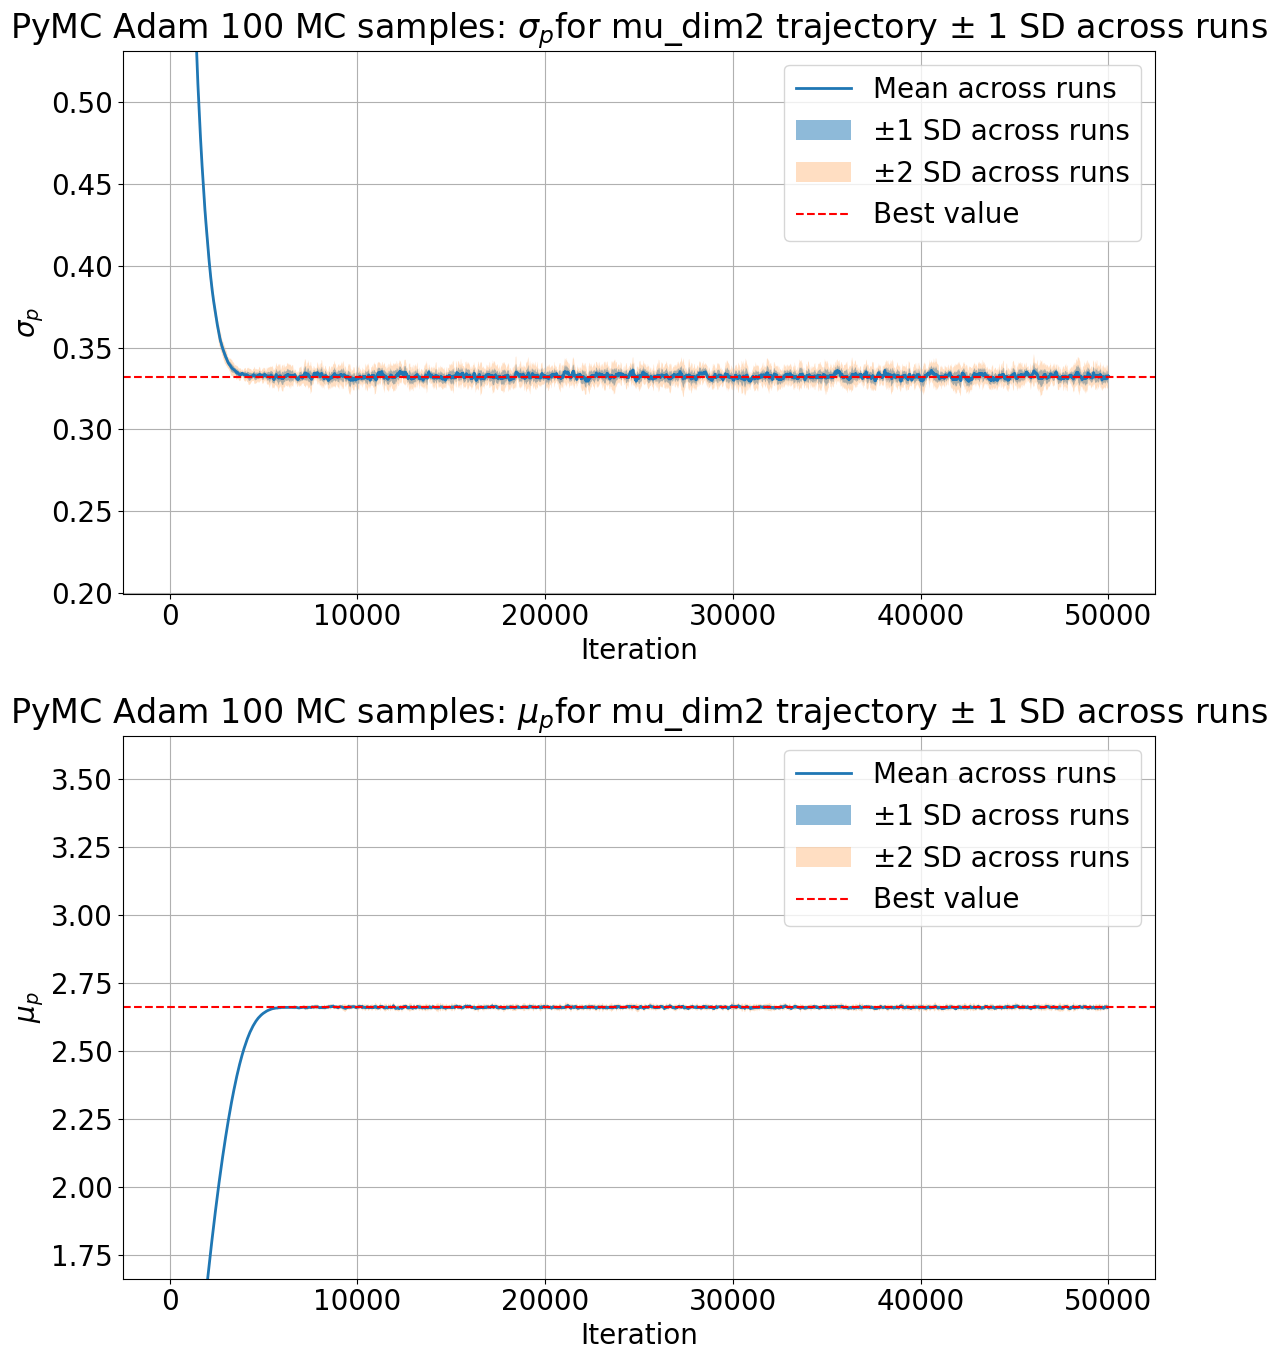

In [ ]:

from modulars.plot_rr import plot_some_dims_multid
which_dims = [0, 1, 2]
plot_some_dims_multid(
    single_means, single_covs, multi_means, multi_covs,
    true_mu_post, true_sigma_post, 'mu', dim,
    which_dims, k=3
)
plot_some_dims_multid(
    adam_single_means, adam_single_covs, adam_multi_means, adam_multi_covs,
    true_mu_post, true_sigma_post, 'mu', dim,
    which_dims, k=3, label_prefix='PyMC Adam '
)

In [ ]:
single_means.shape

(10, 50000, 40)

In [ ]:
from modulars.pymc_rr_test import fit_pymc_fullrank_covariance

with pm.Model() as cov_model:
    mu = pm.Normal('mu', mu_prior, sigma_prior, shape=dim)
    likelihood = pm.Normal('y', mu, sigma=np.ones(dim), observed=observed_data)

    fullrank_mu_post, fullrank_cov_post = fit_pymc_fullrank_covariance(
        cov_model,
        n_mc_samples=100,
        n_iters=50_000,
        optimizer='default',
        seed=0,
    )


Finished [100%]: Average Loss = 260.35


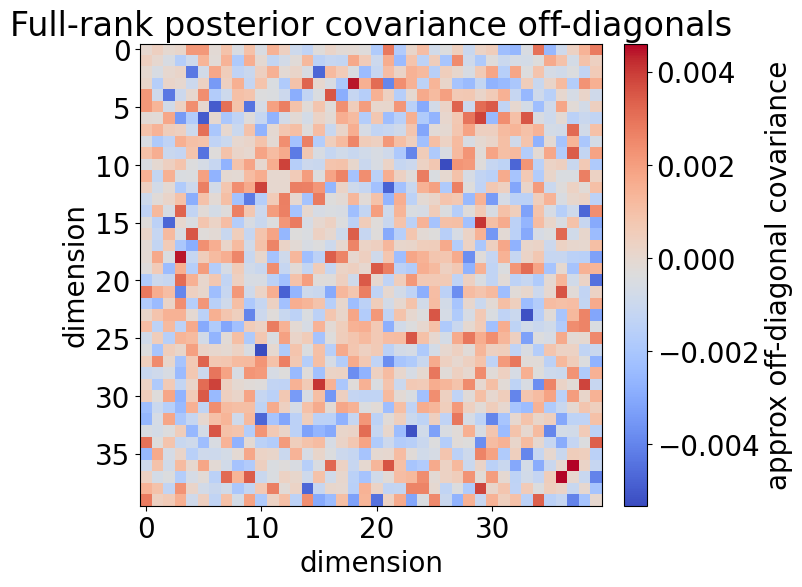

max |offdiag|: 0.005314410460592756
mean |offdiag|: 0.0012864011299214234
max relative offdiag: 0.015996375486384197
mean relative offdiag: 0.0038720674010634844


In [ ]:

fullrank_offdiag = fullrank_cov_post.copy()
np.fill_diagonal(fullrank_offdiag, 0.0)

plt.figure(figsize=(7, 6))
im = plt.imshow(fullrank_offdiag, cmap='coolwarm')
plt.colorbar(im, fraction=0.046, pad=0.04, label='approx off-diagonal covariance')
plt.title('Full-rank posterior covariance off-diagonals')
plt.xlabel('dimension')
plt.ylabel('dimension')
plt.show()

upper_idx = np.triu_indices(dim, k=1)
upper_offdiag = np.abs(fullrank_offdiag[upper_idx])
print('max |offdiag|:', upper_offdiag.max())
print('mean |offdiag|:', upper_offdiag.mean())

print('max relative offdiag:', (upper_offdiag / true_sigma_post[0]).max())
print('mean relative offdiag:', (upper_offdiag / true_sigma_post[0]).mean())



### Why a correlation heatmap?

A covariance heatmap is useful, but raw covariance magnitudes still depend on the marginal scales of each dimension.
In the diagonal-truth case we really care about whether full-rank VI is inventing *spurious dependence*, so it is usually clearer to look at the correlation matrix instead.
Correlation rescales each off-diagonal entry by $\sqrt{\Sigma_{ii} \Sigma_{jj}}$, which puts every pair on the same interpretable scale from -1 to 1.


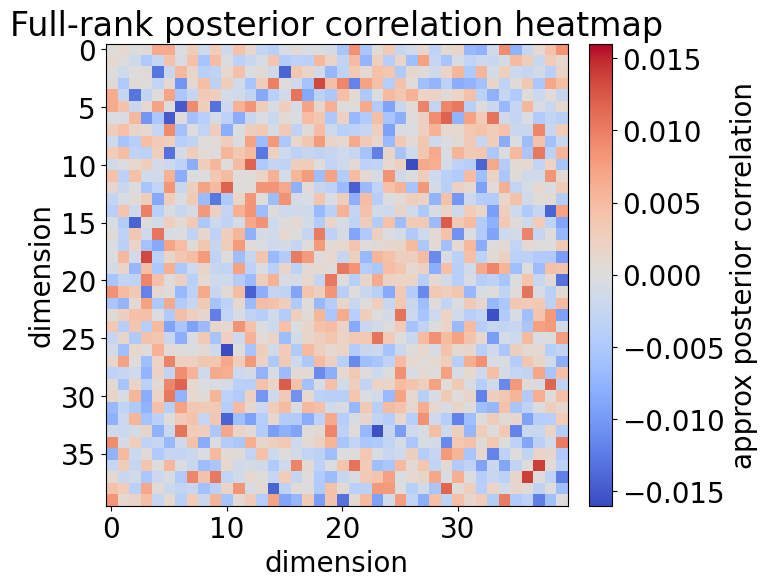

max |offdiag correlation|: 0.01610411312216707
mean |offdiag correlation|: 0.003869032711212411


In [21]:
fullrank_std_post = np.sqrt(np.diag(fullrank_cov_post))
fullrank_corr_post = fullrank_cov_post / np.outer(fullrank_std_post, fullrank_std_post)

plt.figure(figsize=(7, 6))
np.fill_diagonal(fullrank_corr_post, 0.0)
im = plt.imshow(fullrank_corr_post, cmap='coolwarm', vmin=-0.016, vmax=0.016)
plt.colorbar(im, fraction=0.046, pad=0.04, label='approx posterior correlation')
plt.title('Full-rank posterior correlation heatmap')
plt.xlabel('dimension')
plt.ylabel('dimension')
plt.show()

corr_offdiag = fullrank_corr_post.copy()
np.fill_diagonal(corr_offdiag, 0.0)
upper_corr_offdiag = np.abs(corr_offdiag[np.triu_indices(dim, k=1)])
print('max |offdiag correlation|:', upper_corr_offdiag.max())
print('mean |offdiag correlation|:', upper_corr_offdiag.mean())
